# Step 2: Marker Gene Similarity (Stem/Progenitor Only)

## Overview

This notebook calculates cell-cell similarity based on **stem/progenitor marker genes only**.

## Why Only Stem Markers?

1. **Most Relevant**: For glioblastoma trajectory analysis
2. **Captures Stemness Gradient**: From stem-like tumor cells to differentiated states
3. **Simpler**: Easier to interpret and faster to compute
4. **Biologically Meaningful**: Stemness is key for tumor progression

## The Pipeline

```
Step 1: VAE learns general patterns from all genes
Step 2: Calculate similarity from STEM MARKERS only  ← We are here
Step 3: Use similarity to guide latent space → Stem-focused trajectories
```

## Your Data
- **103,426 cells** (3,567 tumor + 99,859 normal)
- **16,388 genes**
- Focus: Stem-like tumor cells vs differentiated normal cells

In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import issparse
from tqdm import tqdm  # Progress bars
import gc  # Garbage collection for memory management
import os
print("✓ Imports successful!")

✓ Imports successful!


In [ ]:
ADATA_PATH = 'models/tumor_normal_integrated.h5ad'
os.makedirs('outputs/cell_similarity_based_on_marker', exist_ok=True)
adata= sc.read_h5ad(ADATA_PATH)
# Check your data
print(adata)
print(adata.obs.columns)  # See available metadata columns

AnnData object with n_obs × n_vars = 103426 × 16388
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'batch', 'condition', 'dataset', '_scvi_batch', '_scvi_labels', 'leiden_scvi'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scvi', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log1p_norm'
    obsp: 'connectivities', 'distances'
Index(['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'n_genes', 'batch', 'condition', 'dataset', '_scvi_batch',
       '_scvi_labels', 'leiden_scvi'],
      dtype='object')


## Part 1: Define Stem/Progenitor Markers

These markers define stemness and are crucial for understanding tumor cell states.

In [3]:
# =============================================================================
# DEFINE STEM/PROGENITOR MARKER GENES ONLY
# =============================================================================

# Focus ONLY on stem/progenitor markers
# These genes define the stem-like state and differentiation trajectory

marker_genes = {
    'stem_progenitor': [
        # Core neural stem cell markers
        'SOX2',      # SRY-box 2 - Master regulator of stemness and self-renewal
        'NES',       # Nestin - Intermediate filament, neural progenitor marker
        'VIM',       # Vimentin - Mesenchymal marker, stem cell associated
        
        # Glial progenitor markers
        'OLIG2',     # Oligodendrocyte lineage transcription factor 2
        'FABP7',     # Fatty acid binding protein 7 - Radial glia marker
        'ASCL1',     # Achaete-scute homolog 1 - Proneural transcription factor
        
        # Cancer stem cell markers
        'PROM1',     # CD133 - Cancer stem cell surface marker (gene name is PROM1)
        'CD44',      # Cell surface glycoprotein - Stem cell marker
        
        # Stem cell signaling pathways
        'NOTCH1',    # Notch signaling - Maintains stem cell state
        'HES1',      # Hairy and enhancer of split 1 - Notch target, maintains stemness
        'JAG1',      # Jagged 1 - Notch ligand
        
        # Additional stem/progenitor markers
        'PAX6',      # Paired box 6 - Neural stem cell transcription factor
        'BMI1',      # B cell-specific Moloney murine leukemia virus integration site 1
                     # Critical for stem cell self-renewal
        'MELK',      # Maternal embryonic leucine zipper kinase - Stem cell marker
        'MSI1',      # Musashi RNA binding protein 1 - Neural stem cell marker
        'MSI2',      # Musashi RNA binding protein 2 - Stem cell marker
    ],
}

# Get flat list of all markers
all_markers = marker_genes['stem_progenitor']

print("="*60)
print("Stem/Progenitor Marker Genes")
print("="*60)
print(f"Total markers: {len(all_markers)}")
print(f"\nMarkers: {', '.join(all_markers)}")
print("\nThese markers will capture:")
print("  - Stem cell self-renewal (SOX2, BMI1, NOTCH1)")
print("  - Neural progenitor state (NES, PAX6, MSI1/2)")
print("  - Glial lineage commitment (OLIG2, FABP7, ASCL1)")
print("  - Cancer stem cell phenotype (PROM1/CD133, CD44)")
print("="*60 + "\n")

Stem/Progenitor Marker Genes
Total markers: 16

Markers: SOX2, NES, VIM, OLIG2, FABP7, ASCL1, PROM1, CD44, NOTCH1, HES1, JAG1, PAX6, BMI1, MELK, MSI1, MSI2

These markers will capture:
  - Stem cell self-renewal (SOX2, BMI1, NOTCH1)
  - Neural progenitor state (NES, PAX6, MSI1/2)
  - Glial lineage commitment (OLIG2, FABP7, ASCL1)
  - Cancer stem cell phenotype (PROM1/CD133, CD44)



## Part 2: Check Marker Availability

Verify which stem markers exist in your 16,388 genes.

In [4]:
# =============================================================================
# CHECK WHICH MARKERS ARE IN YOUR DATASET
# =============================================================================

def check_marker_availability(adata, marker_list):
    """
    Check which marker genes are present in the dataset.
    
    For your data structure:
    - Gene names are in adata.var.index (standard AnnData)
    - We'll do case-insensitive matching
    """
    # Get gene names from adata.var.index
    # This is the standard location for gene names in AnnData
    dataset_genes = set(adata.var.index.str.upper())
    gene_name_map = {g.upper(): g for g in adata.var.index}
    
    # Check each marker
    available = []
    missing = []
    
    for marker in marker_list:
        marker_upper = marker.upper()
        if marker_upper in dataset_genes:
            # Found! Store original name from dataset
            available.append(gene_name_map[marker_upper])
        else:
            missing.append(marker)
    
    # Print results
    print("="*60)
    print("Marker Availability Check")
    print("="*60)
    print(f"\nDataset: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
    print(f"Gene names location: adata.var.index")
    print(f"\nRequested markers: {len(marker_list)}")
    print(f"Available markers: {len(available)} ({100*len(available)/len(marker_list):.1f}%)")
    print(f"Missing markers: {len(missing)} ({100*len(missing)/len(marker_list):.1f}%)")
    
    if available:
        print(f"\n✓ AVAILABLE ({len(available)}):")
        print(f"  {', '.join(available)}")
    
    if missing:
        print(f"\n✗ MISSING ({len(missing)}):")
        print(f"  {', '.join(missing)}")
        print("\n  Note: Missing markers will be ignored.")
        print("        Similarity will be computed from available markers only.")
    
    print("="*60 + "\n")
    
    return available, missing



## Part 3: Extract Marker Expression

Get expression values for available stem markers across all 103K cells.

In [5]:
# =============================================================================
# EXTRACT STEM MARKER EXPRESSION MATRIX
# =============================================================================

def extract_marker_expression(adata, marker_list, use_layer='counts',
                              normalize=True, log_transform=True):
    """
    Extract expression for stem markers with normalization.
    
    Processing steps:
    1. Get raw counts from specified layer
    2. Subset to marker genes only
    3. Normalize by total counts (CPM - counts per million)
    4. Log-transform: log1p(x) = log(1 + x)
    
    Why normalize and log-transform?
    - Cosine similarity works better with normalized data
    - Log reduces the impact of highly expressed genes
    - Focuses on expression patterns rather than magnitudes
    
    Parameters:
    -----------
    adata : AnnData
        Your single-cell dataset
    marker_list : list
        List of available marker gene names
    use_layer : str
        Which data layer to use ('counts' recommended)
    normalize : bool
        Normalize by total counts per cell
    log_transform : bool
        Apply log1p transformation
    
    Returns:
    --------
    marker_expr : np.ndarray, shape (n_cells, n_markers)
        Processed marker expression matrix
    marker_names : list
        Names of markers (column names)
    """
    print("="*60)
    print("Extracting Marker Expression")
    print("="*60)
    print(f"Cells: {adata.n_obs:,}")
    print(f"Markers: {len(marker_list)}")
    print(f"Layer: {use_layer}")
    print(f"Normalize: {normalize}")
    print(f"Log-transform: {log_transform}")
    
    # Get expression data from appropriate layer
    if use_layer in adata.layers:
        X = adata.layers[use_layer]
        print(f"\n✓ Using adata.layers['{use_layer}']")
    else:
        X = adata.X
        print(f"\n✓ Using adata.X (layer '{use_layer}' not found)")
    
    # Convert sparse to dense if needed
    if issparse(X):
        print("  Converting sparse → dense...")
        X = X.toarray()
        print("  ✓ Converted")
    
    # Find indices of marker genes
    gene_names = list(adata.var_names)
    marker_indices = [gene_names.index(m) for m in marker_list if m in gene_names]
    marker_names_found = [gene_names[i] for i in marker_indices]
    
    print(f"\n  Found {len(marker_indices)}/{len(marker_list)} markers in dataset")
    
    # Extract marker columns
    marker_expr = X[:, marker_indices]
    print(f"  Extracted shape: {marker_expr.shape}")
    
    # Normalize by total counts per cell
    if normalize:
        print("\n  Normalizing by total counts...")
        # Sum across markers for this cell
        total_counts = marker_expr.sum(axis=1, keepdims=True)
        # Avoid division by zero
        total_counts[total_counts == 0] = 1
        # Normalize to counts per 10,000 (standard CPM)
        marker_expr = (marker_expr / total_counts) * 10000
        print("  ✓ Normalized (CPM)")
    
    # Log-transform
    if log_transform:
        print("  Applying log1p transform...")
        marker_expr = np.log1p(marker_expr)  # log(1 + x)
        print("  ✓ Log-transformed")
    
    # Summary statistics
    print("\n" + "="*60)
    print("Marker Expression Matrix Summary")
    print("="*60)
    print(f"Shape: {marker_expr.shape}")
    print(f"  → {marker_expr.shape[0]:,} cells")
    print(f"  → {marker_expr.shape[1]} markers")
    print(f"\nValue range: [{marker_expr.min():.3f}, {marker_expr.max():.3f}]")
    print(f"Mean: {marker_expr.mean():.3f}")
    print(f"Std: {marker_expr.std():.3f}")
    print(f"Sparsity: {100 * (marker_expr == 0).sum() / marker_expr.size:.1f}% zeros")
    print("\nMarkers included:")
    print(f"  {', '.join(marker_names_found)}")
    print("="*60 + "\n")
    
    return marker_expr, marker_names_found



## Part 4: Calculate Cosine Similarity

Compute similarity between cells based on stem marker expression.

**Memory considerations**:
- Full matrix (103K × 103K): ~40 GB RAM ❌
- Top-K sparse (k=1000): ~800 MB ✓

We'll use **Top-K** approach for efficiency.

In [6]:
# =============================================================================
# CALCULATE COSINE SIMILARITY (TOP-K APPROACH)
# =============================================================================

def calculate_topk_similarity(marker_expr, top_k=1000, chunk_size=5000):
    """
    Calculate top-k most similar cells for each cell.
    
    Memory-efficient approach:
    - Process cells in chunks
    - Keep only top-k most similar per cell
    - Much faster and uses less RAM
    
    Cosine similarity formula:
        sim(A, B) = (A · B) / (||A|| × ||B||)
    
    Range: -1 (opposite) to +1 (identical)
    
    Parameters:
    -----------
    marker_expr : np.ndarray, shape (n_cells, n_markers)
        Stem marker expression matrix
    top_k : int
        Number of most similar cells to keep per cell
        Recommended: 1000-5000 for 103K cells
    chunk_size : int
        Process this many cells at once
    
    Returns:
    --------
    similarity_dict : dict
        'indices': (n_cells, top_k) indices of most similar cells
        'values': (n_cells, top_k) similarity values
    """
    n_cells = marker_expr.shape[0]
    n_chunks = int(np.ceil(n_cells / chunk_size))
    
    print("="*60)
    print("Computing Cosine Similarity (Top-K)")
    print("="*60)
    print(f"Total cells: {n_cells:,}")
    print(f"Top-K: {top_k}")
    print(f"Chunk size: {chunk_size:,}")
    print(f"Number of chunks: {n_chunks}")
    print(f"\nMemory estimate: ~{n_cells * top_k * 8 / 1e9:.2f} GB")
    print("  (Much better than ~40 GB for full matrix!)\n")
    
    # Initialize storage for top-k results
    top_k_indices = np.zeros((n_cells, top_k), dtype=np.int32)
    top_k_values = np.zeros((n_cells, top_k), dtype=np.float32)
    
    # Process in chunks
    print("Processing chunks...")
    for i in tqdm(range(n_chunks)):
        # Define chunk boundaries
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, n_cells)
        
        # Get this chunk of cells
        chunk = marker_expr[start_idx:end_idx]
        
        # Compute similarity: this chunk vs ALL cells
        # Result shape: (chunk_size, n_cells)
        sim_chunk = cosine_similarity(chunk, marker_expr)
        
        # For each cell in chunk, find top-k most similar cells
        # argsort gives indices in ascending order
        # [:, -top_k:] takes the last (highest) k values
        # [:, ::-1] reverses to get descending order
        top_indices = np.argsort(sim_chunk, axis=1)[:, -top_k:][:, ::-1]
        
        # Extract the actual similarity values for these indices
        top_values = np.take_along_axis(sim_chunk, top_indices, axis=1)
        
        # Store results
        top_k_indices[start_idx:end_idx] = top_indices
        top_k_values[start_idx:end_idx] = top_values
        
        # Clean up to free memory
        del sim_chunk
        if i % 5 == 0:  # Every 5 chunks, force garbage collection
            gc.collect()
    
    print("\n✓ Similarity computation complete!")
    
    # Summary statistics
    print("\n" + "="*60)
    print("Similarity Statistics")
    print("="*60)
    print(f"Result shape: {top_k_values.shape}")
    print(f"  → Each of {n_cells:,} cells has top-{top_k} similar cells")
    print(f"\nSimilarity value range: [{top_k_values.min():.4f}, {top_k_values.max():.4f}]")
    print(f"Mean similarity: {top_k_values.mean():.4f}")
    print(f"Median similarity: {np.median(top_k_values):.4f}")
    print(f"Std similarity: {top_k_values.std():.4f}")
    print("\nInterpretation:")
    print("  1.0 = Identical stem marker profile (same cell or duplicates)")
    print("  0.8-0.9 = Very similar stem state")
    print("  0.5-0.7 = Moderately similar")
    print("  <0.5 = Different stem states")
    print("="*60 + "\n")
    
    return {'indices': top_k_indices, 'values': top_k_values}



## Part 5: Visualize Similarity Patterns

Let's see what the stem-based similarity looks like.

In [ ]:
# =============================================================================
# VISUALIZE STEM-BASED SIMILARITY
# =============================================================================

def plot_similarity_analysis(similarity_dict, adata, sample_size=1000):
    """
    Create visualizations of stem marker similarity patterns.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    indices = similarity_dict['indices']
    values = similarity_dict['values']
    
    # ===== Plot 1: Distribution of Similarities =====
    axes[0, 0].hist(values.flatten(), bins=100, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(values.mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {values.mean():.3f}')
    axes[0, 0].axvline(np.median(values), color='orange', linestyle='--', linewidth=2,
                      label=f'Median: {np.median(values):.3f}')
    axes[0, 0].set_xlabel('Cosine Similarity', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Distribution of Stem Marker Similarities\n(All Top-K Pairs)',
                        fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # ===== Plot 2: Average Similarity per Cell =====
    avg_sim = values.mean(axis=1)
    axes[0, 1].hist(avg_sim, bins=100, color='orange', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(avg_sim.mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {avg_sim.mean():.3f}')
    axes[0, 1].set_xlabel('Average Similarity to Top-K Neighbors', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Number of Cells', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Average Stem Similarity per Cell',
                        fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # ===== Plot 3: Similarity Heatmap (sample) =====
    n_cells = values.shape[0]
    if n_cells > sample_size:
        sample_idx = np.random.choice(n_cells, sample_size, replace=False)
        sample_idx = np.sort(sample_idx)
        sample_values = values[sample_idx]
    else:
        sample_values = values
        sample_idx = np.arange(n_cells)
    
    im = axes[1, 0].imshow(sample_values, aspect='auto', cmap='viridis',
                          vmin=0, vmax=1, interpolation='nearest')
    axes[1, 0].set_xlabel('Top-K Rank', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Cell Index (sampled)', fontsize=12, fontweight='bold')
    axes[1, 0].set_title(f'Similarity Heatmap\n({len(sample_idx):,} cells × top-{values.shape[1]})',
                        fontsize=14, fontweight='bold')
    cbar = plt.colorbar(im, ax=axes[1, 0])
    cbar.set_label('Cosine Similarity', fontsize=10)
    
    # ===== Plot 4: Similarity by Condition =====
    if 'condition' in adata.obs.columns:
        conditions = adata.obs['condition'].values
        unique_conds = np.unique(conditions)
        
        cond_means = []
        cond_stds = []
        cond_labels = []
        
        for cond in unique_conds:
            mask = conditions == cond
            if mask.sum() > 0:
                cond_means.append(avg_sim[mask].mean())
                cond_stds.append(avg_sim[mask].std())
                cond_labels.append(f"{cond}\n(n={mask.sum():,})")
        
        x_pos = np.arange(len(cond_labels))
        axes[1, 1].bar(x_pos, cond_means, yerr=cond_stds,
                      color=['#e74c3c', '#3498db', '#2ecc71'][:len(cond_labels)],
                      alpha=0.7, capsize=5)
        axes[1, 1].set_xticks(x_pos)
        axes[1, 1].set_xticklabels(cond_labels, fontsize=10)
        axes[1, 1].set_ylabel('Average Stem Similarity', fontsize=12, fontweight='bold')
        axes[1, 1].set_title('Stem Similarity by Condition',
                            fontsize=14, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for i, v in enumerate(cond_means):
            axes[1, 1].text(i, v + 0.01, f'{v:.3f}',
                          ha='center', va='bottom', fontweight='bold')
    else:
        axes[1, 1].text(0.5, 0.5, 'No condition metadata\navailable',
                       ha='center', va='center', fontsize=14, transform=axes[1, 1].transAxes)
        axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/cell_similarity_based_on_marker/similarity_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print insights
    print("\n" + "="*60)
    print("Key Insights")
    print("="*60)
    print(f"1. Overall similarity level: {values.mean():.3f}")
    print(f"   → Higher = cells share similar stem profiles")
    print(f"\n2. Similarity spread: {values.std():.3f}")
    print(f"   → Diversity in stem states across cells")
    print(f"\n3. Self-similarity (first neighbor): {values[:, 0].mean():.3f}")
    print(f"   → Should be close to 1.0 (cell similar to itself)")
    
    if 'condition' in adata.obs.columns and len(unique_conds) > 1:
        print(f"\n4. Condition differences:")
        for label, mean in zip(cond_labels, cond_means):
            print(f"   {label.split('(')[0]}: {mean:.3f}")
    print("="*60 + "\n")



In [8]:
# Check availability in your dataset
# Replace 'adata' with your actual AnnData object name if different
available_markers, missing_markers = check_marker_availability(adata, all_markers)

Marker Availability Check

Dataset: 103,426 cells × 16,388 genes
Gene names location: adata.var.index

Requested markers: 16
Available markers: 16 (100.0%)
Missing markers: 0 (0.0%)

✓ AVAILABLE (16):
  SOX2, NES, VIM, OLIG2, FABP7, ASCL1, PROM1, CD44, NOTCH1, HES1, JAG1, PAX6, BMI1, MELK, MSI1, MSI2



In [9]:
# Extract expression for available stem markers
marker_expr, marker_names = extract_marker_expression(
    adata,
    available_markers,
    use_layer='counts',    # Use raw counts
    normalize=True,        # Normalize to CPM
    log_transform=True     # Log-transform for stability
)

Extracting Marker Expression
Cells: 103,426
Markers: 16
Layer: counts
Normalize: True
Log-transform: True

✓ Using adata.layers['counts']
  Converting sparse → dense...
  ✓ Converted

  Found 16/16 markers in dataset
  Extracted shape: (103426, 16)

  Normalizing by total counts...
  ✓ Normalized (CPM)
  Applying log1p transform...
  ✓ Log-transformed

Marker Expression Matrix Summary
Shape: (103426, 16)
  → 103,426 cells
  → 16 markers

Value range: [0.000, 9.210]
Mean: 1.853
Std: 3.153
Sparsity: 73.4% zeros

Markers included:
  SOX2, NES, VIM, OLIG2, FABP7, ASCL1, PROM1, CD44, NOTCH1, HES1, JAG1, PAX6, BMI1, MELK, MSI1, MSI2



In [10]:
# Compute top-1000 similarity
# For 103K cells, this is very manageable (~800 MB)
similarity_topk = calculate_topk_similarity(
    marker_expr,
    top_k=1000,         # Keep 1000 most similar cells per cell
    chunk_size=5000     # Process 5000 cells at a time
)

Computing Cosine Similarity (Top-K)
Total cells: 103,426
Top-K: 1000
Chunk size: 5,000
Number of chunks: 21

Memory estimate: ~0.83 GB
  (Much better than ~40 GB for full matrix!)

Processing chunks...


100%|██████████| 21/21 [06:07<00:00, 17.52s/it]



✓ Similarity computation complete!

Similarity Statistics
Result shape: (103426, 1000)
  → Each of 103,426 cells has top-1000 similar cells

Similarity value range: [0.0000, 1.0000]
Mean similarity: 0.8561
Median similarity: 0.9078
Std similarity: 0.2270

Interpretation:
  1.0 = Identical stem marker profile (same cell or duplicates)
  0.8-0.9 = Very similar stem state
  0.5-0.7 = Moderately similar
  <0.5 = Different stem states



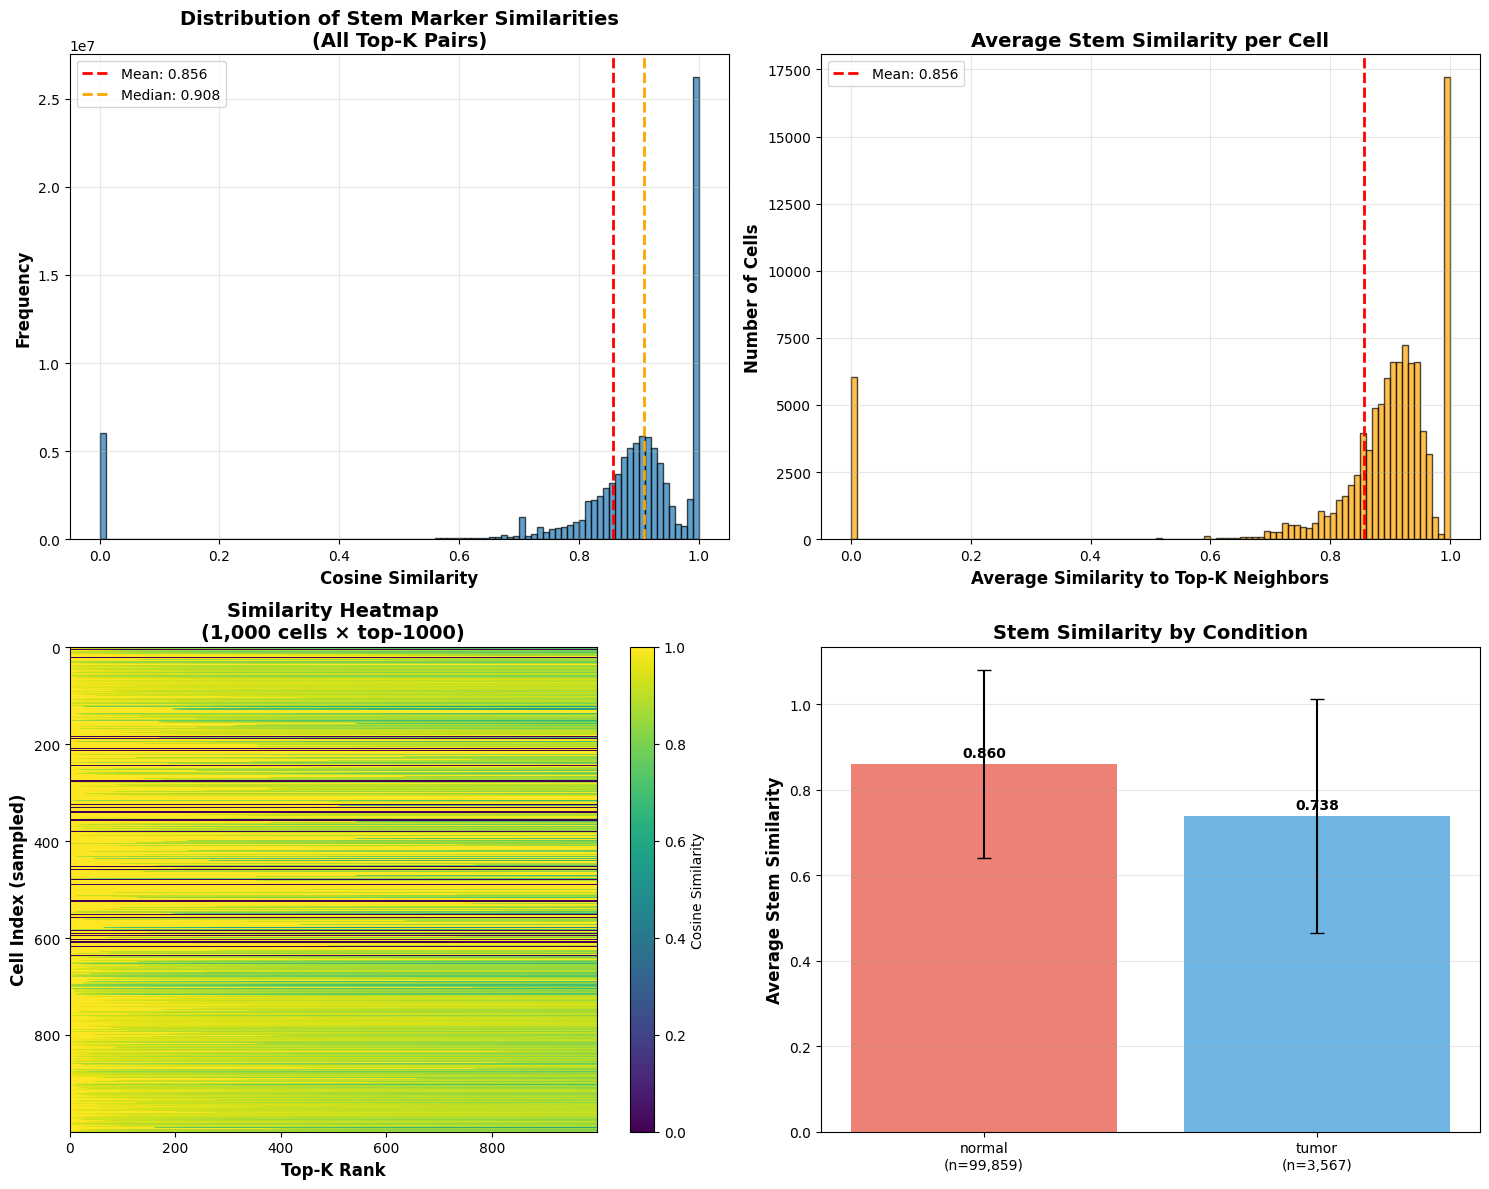


Key Insights
1. Overall similarity level: 0.856
   → Higher = cells share similar stem profiles

2. Similarity spread: 0.227
   → Diversity in stem states across cells

3. Self-similarity (first neighbor): 0.942
   → Should be close to 1.0 (cell similar to itself)

4. Condition differences:
   normal
: 0.860
   tumor
: 0.738



In [11]:
# Create visualizations
plot_similarity_analysis(similarity_topk, adata, sample_size=1000)

## Part 6: Save Results

Save everything for Step 3 (contrastive learning).

In [14]:
# =============================================================================
# SAVE RESULTS FOR STEP 3
# =============================================================================

import pickle
import os 
os.makedirs('models/cosine_similarity_results', exist_ok=True)
# Package everything
step2_results = {
    'marker_genes': marker_genes,           # Original marker definitions
    'available_markers': available_markers, # Markers found in dataset
    'marker_names': marker_names,           # Final marker list used
    'marker_expr': marker_expr,             # Expression matrix (n_cells × n_markers)
    'similarity': similarity_topk,          # Top-K similarity data
    'n_cells': marker_expr.shape[0],
    'n_markers': marker_expr.shape[1],
    'top_k': similarity_topk['values'].shape[1],
}

# Save as pickle
with open('models/cosine_similarity_results/step2_stem_similarity.pkl', 'wb') as f:
    pickle.dump(step2_results, f)

# Also save similarity separately (numpy format for efficiency)
np.savez('models/cosine_similarity_results/step2_similarity_topk.npz',
         indices=similarity_topk['indices'],
         values=similarity_topk['values'])

print("="*60)
print("Results Saved!")
print("="*60)
print("\nFiles created:")
print("  1. step2_stem_similarity.pkl")
print("     → Complete Step 2 results (all data)")
print("\n  2. step2_similarity_topk.npz")
print("     → Similarity matrix only (numpy format)")
print("\nContents:")
for key, value in step2_results.items():
    if isinstance(value, np.ndarray):
        print(f"  {key}: array {value.shape} ({value.dtype})")
    elif isinstance(value, dict):
        print(f"  {key}: dict with keys {list(value.keys())}")
    elif isinstance(value, (int, float)):
        print(f"  {key}: {value}")
    else:
        print(f"  {key}: {type(value).__name__}")
print("\n✓ Ready for Step 3!")
print("="*60)

Results Saved!

Files created:
  1. step2_stem_similarity.pkl
     → Complete Step 2 results (all data)

  2. step2_similarity_topk.npz
     → Similarity matrix only (numpy format)

Contents:
  marker_genes: dict with keys ['stem_progenitor']
  available_markers: list
  marker_names: list
  marker_expr: array (103426, 16) (float32)
  similarity: dict with keys ['indices', 'values']
  n_cells: 103426
  n_markers: 16
  top_k: 1000

✓ Ready for Step 3!


In [13]:
# Get condition labels
is_tumor = (adata.obs['condition'] == 'tumor').values
is_normal = (adata.obs['condition'] == 'normal').values

# For each tumor cell, count how many of its top-1000 neighbors are normal
tumor_indices = np.where(is_tumor)[0]
normal_indices = np.where(is_normal)[0]

# Get neighbors of tumor cells
tumor_neighbors = similarity_topk['indices'][is_tumor]  # Shape: (n_tumor, 1000)

# Check: are the neighbors normal cells?
cross_pop_counts = []
for i, neighbors in enumerate(tumor_neighbors):
    # Count how many neighbors are normal cells
    n_normal_neighbors = is_normal[neighbors].sum()
    cross_pop_counts.append(n_normal_neighbors)

cross_pop_counts = np.array(cross_pop_counts)

print("="*60)
print("Cross-Population Similarity Analysis")
print("="*60)
print(f"  Average normal cells in top-1000: {cross_pop_counts.mean():.1f}")
print(f"  Percentage: {100*cross_pop_counts.mean()/1000:.1f}%")
print(f"  Range: [{cross_pop_counts.min()}, {cross_pop_counts.max()}]")
print("="*60)

Cross-Population Similarity Analysis
  Average normal cells in top-1000: 566.2
  Percentage: 56.6%
  Range: [20, 1000]


## Summary

### What We Accomplished:

1. ✅ **Defined stem/progenitor markers** (16 key genes)
2. ✅ **Checked availability** in your 16,388 genes
3. ✅ **Extracted & processed** marker expression for 103K cells
4. ✅ **Computed top-1000 similarity** for each cell (~800 MB)
5. ✅ **Visualized patterns** to understand stem state structure
6. ✅ **Saved everything** for Step 3

### The Similarity Matrix:

**What it captures:**
- Which cells share similar **stem-like profiles**
- Gradient from high stemness (tumor) to low stemness (differentiated)
- Biological relationships based on key regulatory genes

**Format:**
- For each of 103,426 cells:
  - Top 1000 most similar cells (indices)
  - Their similarity scores (0-1 range)

**Memory:** ~800 MB (very manageable!)

### Next: Step 3 - Contrastive Learning

We'll use this similarity to:
1. **Guide the VAE latent space** toward biological structure
2. **Pull similar cells together** (high similarity)
3. **Push dissimilar cells apart** (low similarity)
4. **Create stem-focused trajectories** for analysis

**Combined training:**
```
Loss = ZINB (reconstruction) + KL (regularization) + λ × Contrastive (biology)
```

### Why This Matters:

The **stem marker similarity** captures:
- Tumor progression states (high stem → differentiated)
- Cell state transitions
- Biologically meaningful relationships

This is **much more informative** than using all genes, which includes:
- Technical noise
- Housekeeping genes
- Irrelevant biological processes

By focusing on **stem markers only**, we get a cleaner signal for trajectory analysis!

---

Ready to proceed to Step 3? 🚀